# 05a — Simplified Self-Attention: Building the Mechanism by Hand

**Lecture goal:** derive the attention mechanism from first principles, with *no trainable parameters at all*, and implement every step in a handful of lines of PyTorch. By the end you'll have turned six embedding vectors into six **context vectors** and understood exactly why each operation is the one it is.

This notebook is a slow companion to `05_self_attention.ipynb`. That notebook races through the non-trainable version in three cells on its way to queries, keys and values; here we stop and take the whole thing apart. If you've already read notebook 05 you'll recognise the code — the point of this one is the *reasoning* behind it. Read this first if the mechanism didn't click, or afterwards to consolidate it.

## What are we actually trying to compute?

Recall where notebook 04 left us. A sentence goes through the tokenizer, comes out as token IDs, and each ID gets looked up in the embedding table to produce a vector. Take the sentence we'll use throughout:

> Your journey starts with one step

Six tokens, six embedding vectors. Each vector captures the meaning of *its own word* — that was the whole achievement of notebook 04, and it's why semantically related words like `"cat"` and `"kitten"` land near each other in that space.

But look at what's missing. The vector for `"journey"` says something about the concept of a journey. It says **nothing** about the fact that `"starts"` is sitting right next to it in this particular sentence, or that `"one"` is barely relevant here, or how much any of the other five words bear on how `"journey"` should be understood. The embedding was computed by a lookup table that never saw the rest of the sentence. It cannot possibly contain that information.

And we need that information. To predict what comes after this sentence, the model has to know which words in it relate to which — the relative importance of `"your"` to `"journey"`, of `"starts"` to `"journey"`, and so on.

So here is the goal of attention, stated once and for all:

> For every input embedding vector, produce a **context vector**: an *enriched* version of that embedding which additionally encodes how the token relates to every other token in the sequence.

That's it. Every attention mechanism in this series — the toy one below, the trainable one in notebook 05, the multi-head causal one in notebook 06 that GPT actually uses — has exactly this job. They differ only in how cleverly they do it.

### Notation

We'll write `x^(i)` for the *i*-th input embedding vector and `z^(i)` for its context vector. So `x^(2)` is the embedding of `"journey"`, and `z^(2)` is what we're after: an enriched `"journey"` vector that knows about the other five words. One `z` per `x`, always — attention doesn't change how many vectors there are, only what's in them.

Throughout, "token" and "word" get used interchangeably. In reality GPT's subword tokenizer might split a word into several tokens (notebook 02), but every word in our example sentence happens to be one token, so the distinction doesn't bite here.

## The toy example

Real embeddings from notebook 04 are 256 numbers wide, and GPT-2's are 768 or more. We'll use **three** dimensions instead. This isn't a simplification of the mechanism — every operation below is exactly what runs inside GPT — it's purely so the numbers fit on screen and so we can plot the vectors and *look* at them.

So: six tokens, each already embedded as a 3-number vector. Pretend the embedding layer produced these.

In [1]:
import torch

inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # Your     x^(1)
    [0.55, 0.87, 0.66],  # journey  x^(2)
    [0.57, 0.85, 0.64],  # starts   x^(3)
    [0.22, 0.58, 0.33],  # with     x^(4)
    [0.77, 0.25, 0.10],  # one      x^(5)
    [0.05, 0.80, 0.55],  # step     x^(6)
])

words = ["Your", "journey", "starts", "with", "one", "step"]

print("inputs.shape:", inputs.shape)
print("  6 rows    = one per token")
print("  3 columns = one per embedding dimension")

inputs.shape: torch.Size([6, 3])
  6 rows    = one per token
  3 columns = one per embedding dimension


Worth being explicit about that shape, because every tensor in this notebook is read the same way: **rows are tokens, columns are embedding dimensions.** `inputs[1]` is all three numbers describing `"journey"`; `inputs[:, 1]` would be the second dimension's value for all six words, which is a much less useful thing to look at.

Since we only have three dimensions, we can plot the six vectors in actual 3-D space. There's no computational reason to do this — you can work through the entire notebook without it — but it makes the next section's argument visible rather than abstract, and it's genuinely striking the first time you see words drawn as arrows.

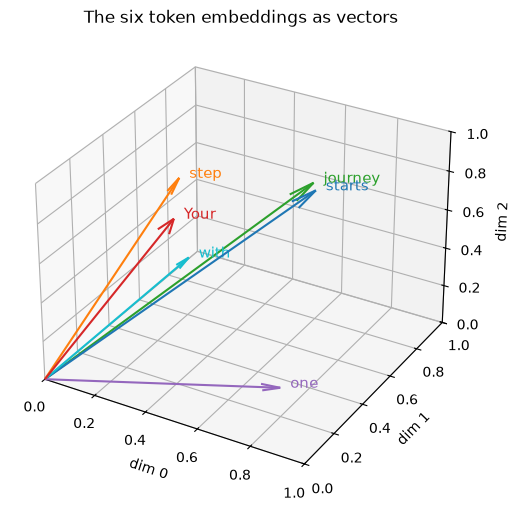

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

colors = ["tab:red", "tab:green", "tab:blue", "tab:cyan", "tab:purple", "tab:orange"]

for (x, y, z), word, color in zip(inputs.tolist(), words, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.08)
    ax.text(x, y, z, f"  {word}", fontsize=11, color=color)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_xlabel("dim 0")
ax.set_ylabel("dim 1")
ax.set_zlabel("dim 2")
ax.set_title("The six token embeddings as vectors")
plt.show()

Look at where the arrows point rather than how long they are. `"journey"` and `"starts"` are almost on top of each other — as you'd hope, since the two words genuinely go together. `"one"` points off in a noticeably different direction. Hold on to that picture; we're about to turn it into arithmetic.

## Step 0: the query

We need a context vector for all six tokens eventually, but doing six at once while also learning the mechanism is a recipe for confusion. So we'll compute *one* — for `"journey"` — completely, and only then generalise.

The token we're currently computing a context vector for is called the **query**. Right now the query is `"journey"`, which is `inputs[1]` (Python indexes from zero, and `"journey"` is the second word).

> The word "query" is doing very little work at this stage — it just means "the token we're focused on". It becomes a technical term with its own weight matrix in notebook 05, and it's worth meeting the name here so it isn't new *and* complicated at the same time.

The question we have to answer is: **for the query `"journey"`, how much attention does each of the six tokens deserve?**

## Step 1: Attention scores, and why the dot product

Suppose you'd never heard of machine learning. You're handed the query vector and six other vectors, and asked to score how important each one is relative to the query. What operation do you reach for?

Rephrase it as a geometry question and the answer usually arrives on its own: *what operation tells you whether two vectors are aligned?*

Look back at the plot. `"journey"` and `"starts"` point nearly the same way — and their meanings are related. `"one"` points off at a wide angle from `"journey"` — and it isn't especially related. Since notebook 04 established that embeddings place similar meanings in similar directions, **alignment is similarity**. So we want a number that's large when two vectors point the same way and small when they don't.

That number is the **dot product**:

```
a . b = a1*b1 + a2*b2 + a3*b3
```

and the reason it works is its geometric form:

```
a . b = |a| |b| cos(theta)
```

where `theta` is the angle between the two vectors. Read off the three cases:

- **Aligned** (`theta = 0`): `cos(0) = 1`, so the dot product is at its maximum.
- **Perpendicular** (`theta = 90`): `cos(90) = 0`, so the dot product is **zero** — no similarity at all.
- **Opposed** (`theta = 180`): `cos(180) = -1`, so the dot product goes negative.

Higher dot product, more aligned, more similar, **more attention**. That's the first key insight of this notebook: the dot product is the operation at the heart of attention, and it's there because it measures alignment.

The jargon for this: the dot product determines the extent to which the elements of a sequence **attend to** one another. Which is a fancier way of saying what we just said — aligned tokens attend to each other, perpendicular ones don't.

We can check the geometry directly before computing any scores. For each word, here's the cosine of its angle with `"journey"`, and the angle itself in degrees.

In [3]:
query = inputs[1]  # "journey"

for word, x_i in zip(words, inputs):
    cos = torch.dot(x_i, query) / (x_i.norm() * query.norm())
    angle = torch.rad2deg(torch.arccos(cos.clamp(-1.0, 1.0)))  # clamp: rounding can push cos past 1
    print(f"{word:>8}:  cos = {cos:.3f}   angle = {angle:5.1f} degrees")

    Your:  cos = 0.781   angle =  38.7 degrees
 journey:  cos = 1.000   angle =   0.0 degrees
  starts:  cos = 1.000   angle =   1.5 degrees
    with:  cos = 0.982   angle =  11.0 degrees
     one:  cos = 0.709   angle =  44.9 degrees
    step:  cos = 0.914   angle =  23.9 degrees


`"starts"` sits about a degree and a half from `"journey"` — practically the same direction — while `"one"` is out at 45 degrees and `"Your"` at 39. Exactly what the plot suggested.

(The angle of `"journey"` with itself is 0, and the `clamp` above is what makes it print as such. Rounding error can leave that cosine a hair over `1.0`, and `arccos` is undefined past 1, so without the clamp you get a `nan` instead of a zero. A small thing, but the kind of small thing that costs an afternoon.)

Now the scores themselves. The **attention score** between the query and an input token is just their dot product, so we loop over the inputs and take one dot product per token.

In [4]:
attn_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)

print("Attention scores for query 'journey':", attn_scores_2)

Attention scores for query 'journey': tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


The `_2` in the name is a reminder that these are the scores belonging to the *second* token — we'll need that once other tokens get their own.

Six numbers, one per token, each saying "here's how much `journey` cares about you." Don't move on until you've checked them against your intuition.

In [5]:
for word, score in zip(words, attn_scores_2):
    print(f"{word:>8}: {score:.4f}")

print()
print("highest:", words[int(attn_scores_2.argmax())])
print("lowest: ", words[int(attn_scores_2.argmin())])

    Your: 0.9544
 journey: 1.4950
  starts: 1.4754
    with: 0.8434
     one: 0.7070
    step: 1.0865

highest: journey
lowest:  one


Read off the ranking and it lines up with the geometry:

- `"journey"` scores highest, which had better be true — a vector is perfectly aligned with itself. A token always attends strongly to itself.
- `"starts"` and `"step"` come next. Both were visibly close to `"journey"` in the plot, and both are related to it in meaning.
- `"one"` scores lowest, and it was the arrow at the widest angle.

One wrinkle worth noticing, now that the angles are on screen: `"with"` sits at a *smaller* angle to `"journey"` (11 degrees) than `"step"` does (24 degrees), yet `"step"` scores higher. That's the `|a| |b|` half of the formula asserting itself — `"with"` is a short vector, so even when well aligned it contributes little. The dot product rewards **both** alignment and magnitude, which is why it is not quite the same thing as cosine similarity.

Make a habit of this. Whenever you see attention scores, ask *why* a particular one is high or low — there's always a geometric answer, and it's the fastest way to catch a bug.

## Step 2: From scores to weights — why normalize?

We could try to build the context vector from these raw scores, but there's a problem, and it's not that the numbers are wrong. It's that they're **uninterpretable**.

Look at them: they don't sum to anything meaningful. I'd like to be able to say "when looking at `journey`, put 23% of your attention on `starts` and only 10% on `one`" — a statement anyone can grasp. I can't say that with these numbers, because as a fraction of *what*?

So we normalize so that the six numbers **sum to 1**. Then each one is a share, a percentage, and the whole thing becomes readable.

There's a second, less obvious reason. Values that sum to 1 are values confined to a sane range, and quantities in a sane range behave far better under gradient descent. We're not training anything in this notebook, but from notebook 10 onward these numbers sit in the middle of a backward pass, and unnormalized values would make that pass numerically unpleasant. Normalization is standard practice across machine learning for exactly this reason.

A terminology note that trips people up constantly:

> **Attention scores** and **attention weights** mean the same thing intuitively — both quantify how much one token matters to another. The only difference is that **attention weights sum to 1** and attention scores don't. Weights are normalized scores.

### The obvious way to normalize

Divide every score by the total.

In [6]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights (simple normalization):", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights (simple normalization): tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


It works — they sum to 1, and we could stop here. But in practice this is *not* what anyone uses, and the reason why is worth understanding properly.

## Step 3: Softmax, and why it's better

The problem with divide-by-the-sum shows up when one value is far larger than the others. Take four numbers where the last one dominates completely: `[1, 2, 3, 400]`.

What *should* a normalization do here? The signal is unambiguous — the fourth value is overwhelming, the first three are noise. Ideally the small ones come out at essentially **0** and the big one at essentially **1**.

Divide-by-the-sum won't do that. The total is 406, so the small values become `1/406`, `2/406`, `3/406` — small, yes, but distinctly nonzero, and the big one lands at `400/406`, which is close to 1 but not close enough. And "not exactly zero" matters: during backpropagation, an optimizer takes those leftover fractions seriously and keeps assigning weight to values that deserve none.

**Softmax** fixes this by exponentiating first:

```
softmax(x)_i = exp(x_i) / sum_j exp(x_j)
```

The values still sum to 1, but the exponential stretches the gaps apart. `exp(400)` is astronomically larger than `exp(3)`, so the dominant value gets essentially all the mass and the rest are crushed toward zero — which is exactly the behaviour we asked for. See it side by side.

In [7]:
extreme = torch.tensor([1.0, 2.0, 3.0, 400.0])

print("divide-by-sum:", (extreme / extreme.sum()))
print("softmax:      ", torch.softmax(extreme, dim=0))

divide-by-sum: tensor([0.0025, 0.0049, 0.0074, 0.9852])
softmax:       tensor([0., 0., 0., 1.])


Divide-by-the-sum leaves the big value at 0.985 with visible crumbs elsewhere; softmax returns a clean `[0, 0, 0, 1]`. When your model has millions of parameters and scores that occasionally blow up, that difference is the difference between a stable training run and a confused optimizer.

Softmax has a second property we get for free and genuinely need: `exp` is always positive, so **attention weights are always positive.** Negative attention would make the percentage interpretation meaningless — what would it mean to pay `-15%` attention to a word?

### Writing softmax ourselves

The formula is one line.

In [8]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)


attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights (naive softmax):", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights (naive softmax): tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


Note the `dim=0`. `attn_scores_2` is a 1-D tensor of six numbers, so there's only one axis to sum over and `dim=0` is it. That argument becomes something to think about once we move to a 2-D matrix later — worth flagging now, and worth deliberately passing the wrong value at that point to see what breaks.

The weights differ from the divide-by-the-sum version, as they must — we exponentiated first — but they still sum to 1.

### Why we use PyTorch's version instead

Our `softmax_naive` is mathematically correct and practically fragile. `torch.exp` of a large number overflows to infinity, and then `inf / inf` gives `nan`, which poisons every computation downstream. Watch it fail on the extreme example.

In [9]:
print("exp(400) =", torch.exp(torch.tensor(400.0)))
print("naive softmax on [1, 2, 3, 400]:", softmax_naive(extreme))

exp(400) = tensor(inf)
naive softmax on [1, 2, 3, 400]: tensor([0., 0., 0., nan])


`inf`, then `nan`. Very small values cause the mirror-image problem, **underflow**, where `exp` rounds to zero.

PyTorch avoids both with one trick: subtract the largest value in the row before exponentiating.

```
softmax(x)_i = exp(x_i - max(x)) / sum_j exp(x_j - max(x))
```

This changes **nothing** mathematically. `exp(x - m)` is `exp(x) / exp(m)`, and that `exp(m)` appears in both numerator and denominator, so it cancels exactly. What it does change is the arithmetic: after the subtraction the largest exponent is `exp(0) = 1`, so nothing can overflow. (This has a habit of showing up in interviews, so it's worth being able to explain.)

Use `torch.softmax` and you get this for free.

In [10]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("Attention weights (torch.softmax):", attn_weights_2)
print("Sum:", attn_weights_2.sum())
print()
print("Same as our naive version?", torch.allclose(attn_weights_2, attn_weights_2_naive))

Attention weights (torch.softmax): tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)

Same as our naive version? True


Identical here, because our scores are all around 1 and nothing overflows. That's precisely why you should still use the library version: the day the values *aren't* tame, you won't have to go looking for the bug.

### Cashing in on interpretability

We normalized so we could read the numbers as percentages. Let's actually read them.

In [11]:
print("With 'journey' as the query, attention is distributed as:")
for word, w in zip(words, attn_weights_2):
    print(f"  {word:>8}: {w * 100:5.1f}%  {'#' * int(round(float(w) * 100))}")

With 'journey' as the query, attention is distributed as:
      Your:  13.9%  ##############
   journey:  23.8%  ########################
    starts:  23.3%  #######################
      with:  12.4%  ############
       one:  10.8%  ###########
      step:  15.8%  ################


Now the mechanism speaks plain English: about 24% of the attention goes to `"journey"` itself, roughly another 23% to `"starts"`, about 16% to `"step"`, and only around 11% to `"one"`. Someone asks how much more `"starts"` matters than `"one"` and you have a number. None of that was sayable two cells ago.

Notice too that the attention is **spread out**, not winner-take-all. Even the least relevant word keeps 11%. That's deliberate: `"one"` isn't important here, but it isn't noise either, and a mechanism that zeroed out everything except the single best match would throw away information the model may need later.

## Step 4: The context vector

Now we cash the weights in. We have six embedding vectors and six numbers saying how much each matters. The context vector is the **weighted sum**: scale each input vector by its attention weight, then add all six together.

Geometrically that's easy to picture. Each arrow in our plot gets shortened in proportion to its share of the attention — `"starts"` keeps most of its length, `"one"` shrinks to a tenth — and then the shortened arrows are laid end to end. Where you land is `z^(2)`.

Two or three lines of code.

In [12]:
context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i] * x_i

print("Context vector for 'journey' z^(2):", context_vec_2)
print("Original embedding      x^(2):", inputs[1])

Context vector for 'journey' z^(2): tensor([0.4419, 0.6515, 0.5683])
Original embedding      x^(2): tensor([0.5500, 0.8700, 0.6600])


Compare the two lines. They're in the same neighbourhood — good, because `"journey"` contributed the largest single share to its own context vector, so `z^(2)` had better still be recognisably about journeys — but they are **not** the same vector. The difference is everything we've built in this notebook.

This is why "enriched embedding" is the right name. `z^(2)` is roughly a quarter `"journey"`, a quarter `"starts"`, a sixth `"step"`, and smaller contributions from the rest. And those proportions aren't arbitrary — each one *is* the relevance of that token to `"journey"`. The relationships between the words are now baked into the numbers, which is exactly the information the plain embedding could never carry.

Here's the shift, drawn.

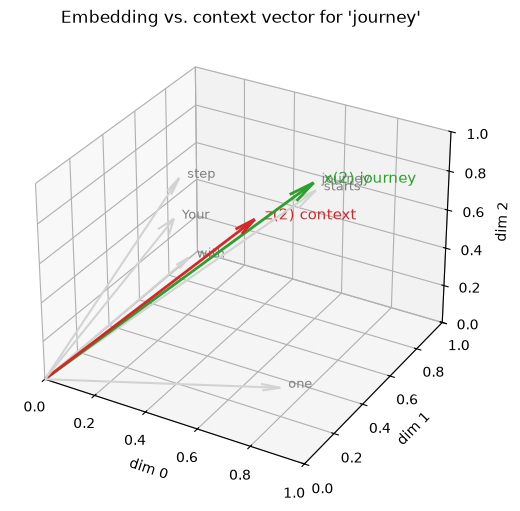

In [13]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for (x, y, z), word in zip(inputs.tolist(), words):
    ax.quiver(0, 0, 0, x, y, z, color="lightgray", arrow_length_ratio=0.08)
    ax.text(x, y, z, f"  {word}", fontsize=9, color="gray")

qx, qy, qz = inputs[1].tolist()
cx, cy, cz = context_vec_2.tolist()

ax.quiver(0, 0, 0, qx, qy, qz, color="tab:green", arrow_length_ratio=0.08, linewidth=2)
ax.text(qx, qy, qz, "  x(2) journey", fontsize=11, color="tab:green")

ax.quiver(0, 0, 0, cx, cy, cz, color="tab:red", arrow_length_ratio=0.08, linewidth=2)
ax.text(cx, cy, cz, "  z(2) context", fontsize=11, color="tab:red")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_xlabel("dim 0")
ax.set_ylabel("dim 1")
ax.set_zlabel("dim 2")
ax.set_title("Embedding vs. context vector for 'journey'")
plt.show()

The red arrow is the green one pulled toward the words that matter — dragged in the direction of `"starts"` and `"step"`, barely influenced by `"one"`. Attention, in one picture.

Everything from here on is the same four steps repeated and vectorised. The mechanism is done.

## Step 5: All six queries at once

`"journey"` isn't special. Every token needs its own context vector, so every token takes its turn as the query: score it against all six inputs, softmax the scores, weight-and-sum. Six queries, six sets of six scores.

Stack those and you get a `6 x 6` **attention score matrix**, and the way to read it is worth pinning down:

> **Row `i`, column `j`** is the attention score between query token `i` and input token `j`.

So row 1 holds the six scores we already computed for `"journey"`, row 2 will be `"starts"`'s scores, and so on. The most direct implementation is two nested loops.

In [14]:
attn_scores_loop = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
        attn_scores_loop[i, j] = torch.dot(x_i, x_j)

print(attn_scores_loop)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Check row 1 against the scores from Step 1 — same six numbers, because row 1 *is* the `"journey"` query. Notice also that the matrix is symmetric: the score between `"journey"` and `"starts"` doesn't depend on which one you call the query, since `a . b = b . a`. (That symmetry is a property of *this* simplified version and it disappears the moment queries and keys get separate weight matrices in notebook 05.)

### Doing it properly: one matrix multiplication

Nested Python loops are slow, and 36 dot products is nothing compared to a real model — GPT-2 with a 1024-token context needs over a million per attention head, per layer. So we don't loop.

The whole matrix is one matrix multiplication:

```
attn_scores = inputs @ inputs.T
```

Why? Because matrix multiplication *is* a batch of dot products: entry `(i, j)` of `A @ B` is the dot product of row `i` of `A` with column `j` of `B`. Take `A = inputs` and `B = inputs.T`, whose columns are the rows of `inputs`, and entry `(i, j)` becomes the dot product of token `i` with token `j` — precisely what the nested loops computed, but dispatched to optimized library code.

This is the reason linear algebra is worth knowing. The difference between the two cells isn't cleverness for its own sake; it's the difference between code that runs and code that doesn't finish.

In [15]:
attn_scores = inputs @ inputs.T

print(attn_scores)
print()
print("Same as the double loop?", torch.allclose(attn_scores, attn_scores_loop))

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

Same as the double loop? True


### Normalizing every row

Same softmax as before, now applied to each of the six rows independently — every query's scores must sum to 1 on their own. That's what `dim=-1` expresses.

`dim` names the axis the operation runs *along*. Our matrix is 2-D: axis 0 walks down the rows, axis 1 (equivalently `-1`, the last) walks across the columns within a row. Passing `dim=-1` therefore softmaxes across each row's six entries, so **each row sums to 1** — one probability distribution per query, which is what we want.

Pass `dim=0` instead and you'd normalize down the columns, producing a matrix whose *columns* sum to 1 and which means nothing at all. Nothing errors out; the numbers just quietly become wrong. This is a detail worth caring about — it's exactly the kind of thing that's easy to skip and expensive to debug.

In [16]:
attn_weights = torch.softmax(attn_scores, dim=-1)

print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


Row 1 should match `attn_weights_2` from Step 3, and every row should sum to 1. Let's not take either on faith.

In [17]:
print("Row 1 matches the 'journey' weights?", torch.allclose(attn_weights[1], attn_weights_2))
print()
print("Row sums (dim=-1):", attn_weights.sum(dim=-1))
print("Column sums, for contrast:", attn_weights.sum(dim=0))

Row 1 matches the 'journey' weights? True

Row sums (dim=-1): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Column sums, for contrast: tensor([0.9220, 1.2970, 1.2788, 0.7974, 0.7540, 0.9508])


Row sums are all 1; column sums are all over the place. That contrast is the whole meaning of the `dim` argument.

### All six context vectors, in one line

Last step, and it collapses to a single matrix product:

```
all_context_vecs = attn_weights @ inputs
```

`attn_weights` is `(6, 6)`, `inputs` is `(6, 3)`, so the result is `(6, 3)` — six context vectors, one per row, each three numbers wide. Same shape as `inputs`, as promised: attention preserves the number of vectors and changes their contents.

Why does this multiplication compute a weighted sum? Work out row 1 of the product. Its first entry is row 1 of `attn_weights` dotted with column 0 of `inputs`; its second entry is that same row dotted with column 1; and so on. Collect the three entries and what you have is

```
w[1,0] * inputs[0] + w[1,1] * inputs[1] + ... + w[1,5] * inputs[5]
```

— each input vector scaled by its attention weight, all of them added. That is the scale-and-sum from Step 4, verbatim. Every row of the product does the same thing for its own query. If that rearrangement didn't quite land, do it once on paper with a `2 x 2` example; it's the single most important matrix manipulation in the transformer and it recurs constantly from here on.

In [18]:
all_context_vecs = attn_weights @ inputs

print("shape:", all_context_vecs.shape)
print(all_context_vecs)

shape: torch.Size([6, 3])
tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


The proof that this is the same computation: row 1 must equal the `context_vec_2` we built with an explicit loop.

In [19]:
print("Row 1 of the matrix version:", all_context_vecs[1])
print("Loop version from Step 4:  ", context_vec_2)
print("Identical?", torch.allclose(all_context_vecs[1], context_vec_2))

manual = sum(attn_weights[1, j] * inputs[j] for j in range(6))
print()
print("Scale-and-sum by hand:     ", manual)
print("Matches the matmul?", torch.allclose(manual, all_context_vecs[1]))

Row 1 of the matrix version: tensor([0.4419, 0.6515, 0.5683])
Loop version from Step 4:   tensor([0.4419, 0.6515, 0.5683])
Identical? True

Scale-and-sum by hand:      tensor([0.4419, 0.6515, 0.5683])
Matches the matmul? True


That's the entire simplified self-attention mechanism, and it fits in three lines:

```python
attn_scores = inputs @ inputs.T
attn_weights = torch.softmax(attn_scores, dim=-1)
all_context_vecs = attn_weights @ inputs
```

Nothing is hidden in those three lines any more. Line 1 is every pairwise dot product, because dot products measure alignment. Line 2 turns scores into interpretable, positive, sum-to-one weights without overflowing. Line 3 is scale-and-sum for all six queries simultaneously.

Keep this shape in mind, because it survives almost unchanged into the real thing. In notebook 05 that third line becomes `attn_weights @ values` — the `inputs` are replaced by a learned projection called *values*, and the two `inputs` in line 1 become learned projections called *queries* and *keys*. The structure and the intuition are identical. Understand these three lines and queries/keys/values are a small step rather than a leap.

## Why this isn't enough: the case for trainable weights

There are no learnable parameters anywhere above. Nothing to train, nothing to optimize — the attention weights fall straight out of the embeddings via a fixed dot product. That's what made the mechanism easy to see, and it's also its fatal limitation.

Here's the flaw. The only reason `"starts"` received a lot of attention from `"journey"` is that the two embeddings happen to point in a similar direction — that is, the two words are **similar in meaning**. Semantic similarity is the *only* signal a bare dot product can pick up.

But relevance and similarity are not the same thing. A word can be crucial to understanding another without resembling it at all. Consider:

> The cat sat on the mat because it is **warm**.

Query: `"warm"`. What does it need to attend to? `"mat"`, obviously — the mat is the thing that's warm; that's the whole point of the sentence.

Now ask what our mechanism would do. `"warm"` and `"mat"` are not semantically similar. One is a temperature, the other is an object; their embeddings point in largely unrelated directions, close to perpendicular. So the dot product between them is small, the attention weight is small, and the mechanism **misses the single most important connection in the sentence.** It would instead hand attention to whatever words happen to look like `"warm"`, which may be none of them.

The problem is that a fixed dot product can only ever ask "do these two words mean similar things?" What we need it to ask is "**in this sentence, does this word matter to that one?**" — and that is a question about context and usage, not about static meaning.

The fix is to stop comparing the raw embeddings. Instead, pass each embedding through a **learned linear projection** before taking the dot product, and let training decide what those projections should be. Given enough text, the model can learn a projection under which `"warm"` and `"mat"` *do* align, because making them align lowers the prediction loss — the model has read enough sentences to know that things like mats are the sorts of things described as warm. The alignment is learned from data rather than inherited from the embedding space.

Those projections are the **query**, **key** and **value** weight matrices, and building them is exactly what notebook 05 does. Everything you'll add there sits on top of the three lines above; the mechanism doesn't change, it just gets parameters.

This is also what makes long-range dependencies learnable rather than accidental. Recall the example from notebook 05's introduction — "the cat that was sitting on the mat ... **jumped**" — where `"jumped"` must connect to `"cat"` across two intervening clauses. Distance is no obstacle here: every token is one weighted lookup from every other. What *would* be an obstacle is a mechanism that only connects words that resemble each other. Trainable weights remove that limitation.

## Recap

- The goal of **every** attention mechanism, simplified or multi-head, is the same: turn each input embedding `x^(i)` into a **context vector** `z^(i)` — an enriched embedding that also encodes how that token relates to every other token in the sequence.
- A plain embedding cannot contain that information, because the lookup table that produced it never saw the rest of the sentence.
- **Attention scores** come from **dot products**, and the dot product is the right operation because `a . b = |a||b|cos(theta)` makes it a measure of alignment: aligned vectors score high, perpendicular ones score zero.
- **Attention weights** are normalized attention scores. Same intuition, but they sum to 1 — which buys interpretability ("23% of the attention goes to `starts`") and numerical stability during training.
- **Softmax** beats divide-by-the-sum because it pushes dominant values toward 1 and the rest toward 0 instead of leaving misleading crumbs, and it guarantees positive weights. Use `torch.softmax`: it subtracts the row maximum first, which is mathematically a no-op but prevents overflow and underflow.
- A **context vector** is the attention-weighted sum of all input vectors — scale each embedding by its weight, then add.
- The whole mechanism vectorises to three lines: `inputs @ inputs.T`, `softmax(..., dim=-1)`, `attn_weights @ inputs`. `dim=-1` normalizes across each row, so each query's weights sum to 1.
- Matrix multiplication *is* a batch of dot products, and `attn_weights @ inputs` *is* scale-and-sum done for every query at once. Both facts are worth verifying on paper.
- The mechanism's limitation: a fixed dot product can only detect **semantic similarity**, so `"warm"` fails to attend to `"mat"` even though the mat is the thing that's warm. **Trainable** query/key/value projections let the model learn contextual relevance instead — which is notebook 05.